# Plotting DE markers

In [2]:
here::i_am("rna/mapping/run/mnn/mapping_mnn.R")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

# Load packages
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(org.Mm.eg.db))
suppressPackageStartupMessages(library(ggrastr))

options(repr.plot.width=25, repr.plot.height=10)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code



In [3]:
args = list()
args$sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')
args$celltypes = opts$celltypes
args$outdir = file.path(io$basedir, 'results/rna/differential')
args$meta = file.path(io$basedir, 'results/rna/mapping/sample_metadata_after_mapping.txt.gz')

In [4]:
meta = fread(args$meta)
sce = readRDS(args$sce)

# Analysis

Eomes, Foxa2, Sox17 (Eomes + two main DE lineage determinants)

T, Cer1, Lhx1, Gsc, Hhex, Mesp1, Cyp26a1 (further DE markers, a cardiac marker (Mesp1) that is also regulated by Eomes, some primitive streak/mesodermal markers such as T and Cer1)

Gata4 (later marker for pancreas, which is endoderm-derived)

Sfrp1 (WNT regulator), Ovol2 (EMT regulator bound by Foxa2), Nanog (pluripotency marker expressed in the epiblast) (these are a little more weird and wonderful -- Ita, our postdoc, and I were spitballing a bit)

oh and maybe also Gata6 -- it's also a pancreatic regulator and also works together with Eomes in human endoderm differentiation

and Mixl1 which is an early mesoderm marker actuvated by Eomes too


In [5]:
markers = c('Eomes', 
            'Foxa2',
            'Sox17', 
            'T', 
            'Cer1', 
            'Lhx1', 
            'Gsc',
            'Hhex', 
            'Mesp1', 
            'Cyp26a1',
            'Gata4', 
            'Sfrp1', 
            'Ovol2',
            'Nanog',
            'Gata6',
            'Mixl1',
           'Cxcr4')

In [11]:
unique(meta$celltype)

[1] "Epiblast"                       NA                              
 [3] "Rostral_neurectoderm"           "PGC"                           
 [5] "Primitive_Streak"               "Def._endoderm"                 
 [7] "Forebrain_Midbrain_Hindbrain"   "NMP"                           
 [9] "Nascent_mesoderm"               "Parietal_endoderm"             
[11] "Caudal_epiblast"                "Anterior_Primitive_Streak"     
[13] "Surface_ectoderm"               "ExE_ectoderm"                  
[15] "Visceral_endoderm"              "Somitic_mesoderm"              
[17] "Paraxial_mesoderm"              "Caudal_neurectoderm"           
[19] "Intermediate_mesoderm"          "Caudal_Mesoderm"               
[21] "Spinal_cord"                    "Mixed_mesoderm"                
[23] "Pharyngeal_mesoderm"            "Haematoendothelial_progenitors"
[25] "Neural_crest"                   "Endothelium"                   
[27] "Notochord"                      "Gut"                           
[29] "Blood_progenitors_1"

In [37]:
sce_markers = sce[markers,]
sce_markers = logNormCounts(sce_markers)

In [38]:
sce_markers

class: SingleCellExperiment 
dim: 17 59525 
metadata(0):
assays(2): counts logcounts
rownames(17): Eomes Foxa2 ... Mixl1 Cxcr4
rowData names(0):
colnames(59525): RBG43471#AAACAGCCAACACTTG-1
  RBG43471#AAACAGCCACATACTG-1 ... RBG43478#TTTGTTGGTTAGGTTG-1
  RBG43478#TTTGTTGGTTGGTTGA-1
colData names(11): barcode sample ... pass_rnaQC sizeFactor
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [39]:
ct_keep = c('Primitive_Streak', 'Anterior_Primitive_Streak', 'Def._endoderm','Notochord', 'Gut','PGC', 'Nascent_mesoderm', 'Intermediate_mesoderm', 'Somitic_mesoderm', 'Rostral_neurectoderm', 'Forebrain_Midbrain_Hindbrain', 'Surface_ectoderm')

In [91]:
marker_expr = lapply(ct_keep, function(ct){
    meta_tmp = meta[celltype==ct]
        tmp = rbind(data.table(gene = markers,
                         mean = rowMeans(logcounts(sce_markers[,meta_tmp[genotype=='WT', cell]])) %>% round(2),
                         perc_expr = rowMeans(logcounts(sce_markers[,meta_tmp[genotype=='WT', cell]])>0) %>% round(2),
                         genotype = 'WT'),
              data.table(gene = markers,
                         mean = rowMeans(logcounts(sce_markers[,meta_tmp[genotype=='Eomes_KO', cell]])) %>% round(2),
                         perc_expr = rowMeans(logcounts(sce_markers[,meta_tmp[genotype=='Eomes_KO', cell]])>0) %>% round(2),
                         genotype = 'Eomes_KO')) %>%
                .[,celltype:=ct]
    
        return(tmp)
    }) %>% rbindlist(.) %>%
        .[,`:=`(genotype=factor(genotype, levels=c('WT', 'Eomes_KO')),
                celltype=factor(celltype, levels=ct_keep),
                gene=factor(gene, levels=rev(markers)))]

Warning message:
“Removed 34 rows containing missing values (geom_point).”


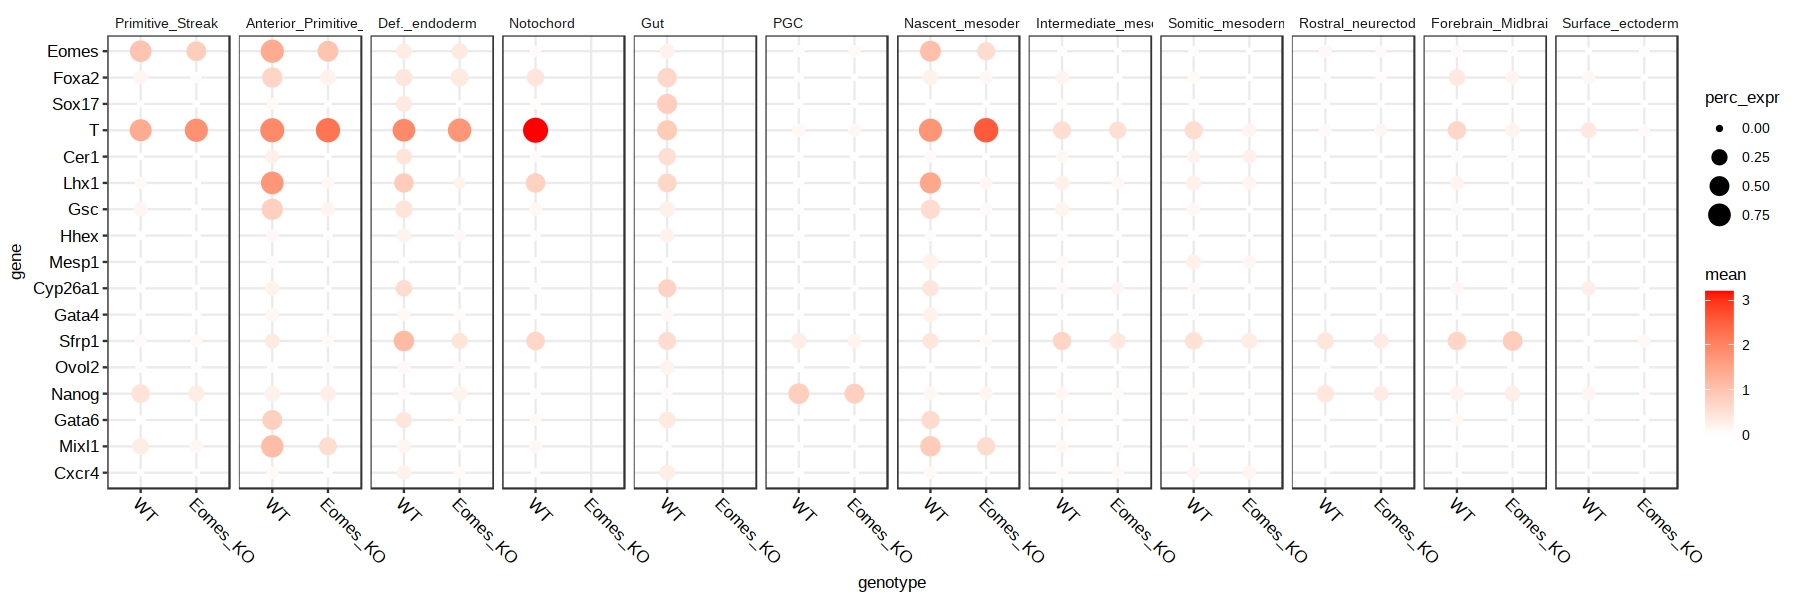

In [92]:
plot = ggplot(marker_expr, aes(genotype, gene, size=perc_expr, col=mean)) +
    geom_point() + 
    scale_colour_gradient2(low='white', high='red') + 
    facet_wrap(~celltype, nrow=1) + 
    theme_bw() + 
    theme(text = element_text(size=10, color='black'),
            axis.text = element_text(size=10, color='black'),
            axis.text.x=element_text(angle=-45, hjust=0, vjust=1),
            strip.background = element_blank(),
             strip.text = element_text(angle=0, hjust=0, vjust=0))

options(repr.plot.width=15, repr.plot.height=5)
plot 

In [93]:
pdf(sprintf('%s/results/rna/differential/markers_dotplot.pdf', io$basedir), width=13, height=5)
     plot
dev.off()

Warning message:
“Removed 34 rows containing missing values (geom_point).”


png 
  2